In [185]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [149]:
# extracting area feature

In [187]:
affected_area_feature_1 = []

In [189]:
affected_area_feature_2 = []

In [191]:
folder_path_affected_fruit = "Dataset/affected"

In [193]:
affected_image_names = [f for f in os.listdir(folder_path_affected_fruit)]

In [195]:
affected_image_names = sorted(affected_image_names)

In [197]:
len(affected_image_names)

335

In [199]:
masking_lower_bound = np.array([9, 23, 98])
masking_upper_bound = np.array([224, 234, 243])

In [201]:
for affected_image_name in affected_image_names:
    affected_image_path = os.path.join(folder_path_affected_fruit, affected_image_name)
    image = cv2.imread(affected_image_path)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    binary_image = cv2.inRange(hsv_image, masking_lower_bound, masking_upper_bound)
    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    largest_contour = sorted_contours[0]
    second_largest_contour = sorted_contours[1]
    affected_area_feature_1.append(cv2.contourArea(second_largest_contour))
    sum_of_two_largest_areas = cv2.contourArea(largest_contour) + cv2.contourArea(second_largest_contour)
    affected_area_feature_2.append(sum_of_two_largest_areas)

In [203]:
healthy_area_feature_1 = []
healthy_area_feature_2 = []

In [205]:
folder_path_healthy_fruit = "Dataset/healthy"

In [207]:
healthy_image_names = [f for f in os.listdir(folder_path_healthy_fruit)]

In [209]:
len(healthy_image_names)

413

In [211]:
for healthy_image_name in healthy_image_names:
    healthy_image_path = os.path.join(folder_path_healthy_fruit, healthy_image_name)
    image = cv2.imread(healthy_image_path)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    binary_image = cv2.inRange(hsv_image, masking_lower_bound, masking_upper_bound)
    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    largest_contour = sorted_contours[0]
    second_largest_contour = sorted_contours[1]
    healthy_area_feature_1.append(cv2.contourArea(second_largest_contour))
    sum_of_two_largest_areas = cv2.contourArea(largest_contour) + cv2.contourArea(second_largest_contour)
    healthy_area_feature_2.append(sum_of_two_largest_areas)

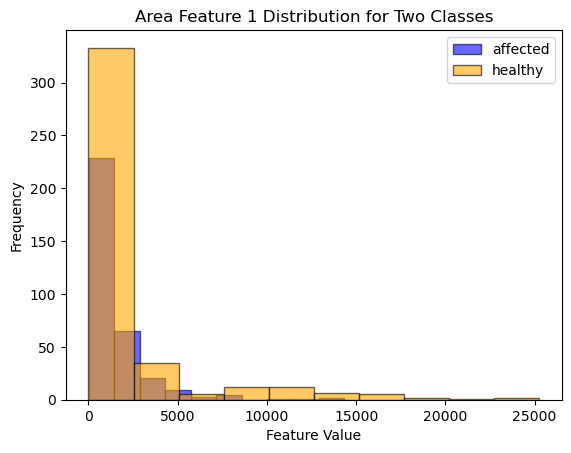

In [213]:
# Plot histograms
plt.hist(affected_area_feature_1, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_area_feature_1, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Area Feature 1 Distribution for Two Classes')
plt.legend()

plt.show()

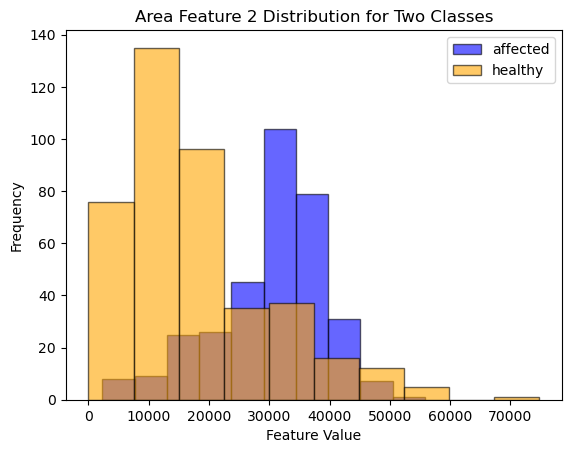

In [215]:
# Plot histograms
plt.hist(affected_area_feature_2, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_area_feature_2, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Area Feature 2 Distribution for Two Classes')
plt.legend()

plt.show()

In [217]:
with open('affected_area_feature_2.pkl', 'wb') as f:
    pickle.dump(affected_area_feature_2, f)

In [219]:
with open('healthy_area_feature_2.pkl', 'wb') as f:
    pickle.dump(healthy_area_feature_2, f)